# Plots for the paper

## Style for plots

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# LINE_WIDTH = 6.75

# HALF_WIDTH = 3.375
# THIRD_WIDTH = 2.25
# QUARTER_WIDTH = 1.6875

ASPECT_RATIO = 4/3

LINE_WIDTH = 7.25 # 5.5 # 6.75

HALF_WIDTH = LINE_WIDTH/ 2 #   3.375
THIRD_WIDTH = LINE_WIDTH/3  # 2.25
QUARTER_WIDTH = LINE_WIDTH/4 # 1.6875

FIG_SIZE_BIG = (HALF_WIDTH*ASPECT_RATIO, HALF_WIDTH) # in inches
FIG_SIZE_MIDDLE = (THIRD_WIDTH*ASPECT_RATIO, THIRD_WIDTH) # in inches
FIG_SIZE_SMALL = (QUARTER_WIDTH*ASPECT_RATIO, QUARTER_WIDTH) # in inches 
FONT_SIZE_MAIN = 10
FONT_SIZE_SMALL = 8
plt.rc('font', size=FONT_SIZE_MAIN)          # controls default text sizes
plt.rc('axes', titlesize=FONT_SIZE_MAIN)     # fontsize of the axes title
plt.rc('axes', labelsize=FONT_SIZE_MAIN)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=FONT_SIZE_SMALL)    # fontsize of the tick labels
plt.rc('ytick', labelsize=FONT_SIZE_SMALL)    # fontsize of the tick labels
plt.rc('legend', fontsize=FONT_SIZE_MAIN)    # legend fontsize


## Reading the data

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

attack_results = json.load(open("experiments/models/consolidated_attack_results_dict.json", "r"))
fp_configs = attack_results["fp_hash_to_config"]
attack_results = attack_results["results"]
utils_results = json.load(open("experiments/utility_results/all_utils.json", "r"))
baseline_utils = json.load(open("experiments/utility_results/baseline_utils.json", "r"))

util_datasets = {"gsm8k": "exact_match,flexible-extract" ,
                  "ifeval": "inst_level_loose_acc,none", 
                  "gpqa_diamond_cot_n_shot_longer": "exact_match,flexible-extract",
                  "bbh_cot_fewshot_no_return": "exact_match,get-answer",
                  "triviaqa": "flexible_match",
                  "triviaqa_longer": "flexible_match",
                  "mmlu_generative": "exact_match,none"}

attack_to_final_name_short = {"ImprobableTokenWithThresholdLogitsProcessor": "IR", "BlockTopWordLogitProcessor": "SLN", "LookaheadAttackedModel": "LD", "baseline": "Base"}
attack_to_final_name = {"ImprobableTokenWithThresholdLogitsProcessor": "ImprobableResponse", "BlockTopWordLogitProcessor": "SuppressLexicalNeighbourhood", "LookaheadAttackedModel": "LookaheadDetection", "baseline": "Baseline"}
metric_to_final_name = {"detailed/fp_in_response_normalized_str_original": "PM", "detailed/fp_in_response_normalized_str": "KM"}




### Helpers

In [121]:

import numpy as np

def is_float(element: any) -> bool:
    #If you expect None to be passed:
    if element is None: 
        return False
    try:
        float(element)
        return True
    except ValueError:
        return False

def check_dict_equality(dict1, dict2, pop_keys=["top_k_to_perturb"]):
    
    if isinstance(dict1, str):
        dict1 = json.loads(dict1)
    if isinstance(dict2, str):
        dict2 = json.loads(dict2)
    for k in pop_keys:
        if k in dict1:
            del dict1[k]
        if k in dict2:
            del dict2[k]
    for k in dict1:
        if k not in dict2:
            # print(f"{k} not in dict2")
            return False
        value1 = dict1[k]
        value2 = dict2[k]
        value1 = str(value1)
        value2 = str(value2)
        if is_float(value1) and is_float(value2):
            value1 = float(value1)
            value2 = float(value2)
            if abs(value1 - value2) > 1e-6:
                # print(f"{k} not equal in dict2, values: {dict1[k]} and {dict2[k]}")
                return False
        else:
            if value1 != value2:
                # print(f"{k} not equal in dict2, values: {dict1[k]} and {dict2[k]}")
                return False
    for k in dict2:
        if k not in dict1:
            # print(f"{k} not in dict1")
            return False
    return True

def get_utils_safely(model, attack_name, attack_kwargs, utils_results, util_datasets, multi_util_aggregation=max):
    try:
        if attack_name not in utils_results[model]:
            return {}
        prim_utils = utils_results[model][attack_name][attack_kwargs]
    except KeyError as e:
        trial_kwargs = attack_kwargs.replace(", 'top_k_to_perturb': '16'", '')
        if '"threshold": "0.91"' in trial_kwargs:
            trial_kwargs = attack_kwargs.replace('"threshold": "0.91"', '"threshold": "0.9"')
            
            try:
                prim_utils = utils_results[model][attack_name][trial_kwargs]
            except KeyError as e:
                found_key = None
                for trial_key in utils_results[model][attack_name].keys():
                    if check_dict_equality(trial_key, attack_kwargs):
                        found_key = trial_key
                        break
                if found_key:        
                    try:    
                        prim_utils = utils_results[model][attack_name][found_key]
                    except KeyError as e:
                        return {}

                else:
                    return {}
        else:
            found_key = None
            for trial_key in utils_results[model][attack_name].keys():
                if check_dict_equality(trial_key, attack_kwargs):
                    found_key = trial_key
                    # points_for_pareto.append((prim_fsr, mean_util))
                    break
            if found_key:        
                try:    
                    prim_utils = utils_results[model][attack_name][found_key]
                except KeyError as e:
                    return {}

            else:
                return {}
    final_utils = {}
    for dataset in util_datasets:
        if dataset not in prim_utils:
            return {}
        try:
            final_utils[dataset] = multi_util_aggregation(prim_utils[dataset])
        except Exception as e:
            print(f"Error getting utility for {dataset} {e}")
            print(f"Rest of the params - {prim_utils} {attack_name} {attack_kwargs} {model}")
            raise e
    return final_utils


# def remove_points(points, threshold=0.05):
#     # Removes points where x is same
#     points = np.asarray(points)
#     x, y = points[:,0], points[:,1]
#     order = np.argsort(x)
#     x = x[order]
#     y = y[order]
    
#     final_x = []
#     final_y = []
    
#     iter_idx = 0
    
#     while iter_idx < len(x):
#         curr_x = x[iter_idx]
#         curr_y = y[iter_idx]
#         for j in range(iter_idx+1, len(x)):
#             if x[j] - curr_x > threshold:
#                 iter_idx = j
#                 break
#             else:
#                 curr_y = max(curr_y, y[j])
#         # print(f"Adding point {curr_x}, {curr_y} at index {iter_idx} of {len(x)}")
#         final_x.append(curr_x)
#         final_y.append(curr_y)
        
#         if iter_idx == len(x) - 1 or j == len(x) - 1:
#             break
#     # Sort by x
#     final_x, final_y = np.array(final_x), np.array(final_y)
#     order = np.argsort(final_x)
#     final_x = final_x[order]
#     final_y = final_y[order]
#     return np.column_stack([final_x, final_y])

import numpy as np

def remove_points(points, threshold=0.05, inclusive=False, max_x=1.5):
    # merges points whose x are within threshold; keeps max y per cluster
    points = np.asarray(points)
    if points.size == 0:
        return points.reshape(0, 2)

    x, y = points[:, 0], points[:, 1]
    order = np.argsort(x)
    x, y = x[order], y[order]

    n = len(x)
    i = 0
    out_x, out_y = [], []
    cmp = (lambda dx: dx >= threshold) if inclusive else (lambda dx: dx > threshold)

    while i < n:
        start_x = x[i]
        max_y = y[i]
        j = i + 1
        while j < n and not cmp(x[j] - start_x):
            if y[j] > max_y:
                max_y = y[j]
            j += 1
        if start_x <= max_x:
            out_x.append(start_x)
            out_y.append(max_y)
        i = j  # jump to first x that starts a new cluster

    out_x = np.asarray(out_x)
    out_y = np.asarray(out_y)
    order = np.argsort(out_x)
    return np.column_stack([out_x[order], out_y[order]])


def pareto_points(points):
    # Goes from left -> right. Adds a point iff y_2 > curr_y
    deduped_points = remove_points(points, threshold=0.0)
    x, y = deduped_points[:,0], deduped_points[:,1]
    final_x, final_y = [], []
    curr_x = x[0]
    curr_y = y[0]
    
    final_x.append(curr_x)
    final_y.append(curr_y)
    
    for i in range(1, len(x)):
        # print(f"Checking point {x[i]}, {y[i]} with curr_y {curr_y}")
        if y[i] > curr_y:
            curr_y = y[i]
            final_x.append(x[i])
            final_y.append(y[i])

    final_x, final_y = np.array(final_x), np.array(final_y)
    order = np.argsort(final_x)
    final_x = final_x[order]
    final_y = final_y[order]
    return np.column_stack([final_x, final_y])
        
        

## Data

In [94]:

model_fp_to_hash = {'meta-llama/llama-3.2-1b-instruct': {
    '16': {
        'chain_hash': ['77daecbbc256a352adfd67909c28df47ad9b7c3ea4d52fad9dc57293d045f9f1', '73b93ed1c5f35c52e7852b949dd01bc66c7ccd9f4627c70c8e27eb1670d61073'],
        'instructional_fp': ['c347e0ff3736c555aee03eec29251da8252226ee832072cf403497158e70f557', 'e749874320b7178beb782f71a06f0d3c1cba9c432d37b723135bc8ee58c3dffd'],
        'perinucleus': ['5f602eba2013151f1af1ad5d069704fdbc5ee53623ead77af62adaa54405b8ac'],
        'fpedit': ['728e1b2e23c52010fb060e5a473fd1e32435cf9bbfa82cfee7a4fc879b71d8a6'],
        'imf': ['66caf8423b5f660cee2cae678fa8d12bd62c21a03668cf0ed9315703304b1dce'],
        'editMF': ['5a569b091450d434d3ffd11cecb12ba2ba9c670066771d0d6172fc55725c0027']
    },
    '128': {
        'chain_hash': ['36c3f2a9fa49ca1a8e5e8469746939958c3dde4a411709f1044bc35c85dacaae', '5d229427dfde4c58f8920ba749b6bb8222960dfdeac9af8ab4e534c7b759015a'],
        'instructional_fp': ['d609a3610a07e82807361cd2974638243b44a8a112a3374fdd4f81c28b1885b8'],
        'perinucleus': ['ae7d43559ac561d476397f7f6201b0c4492b918fc9463084b153a968b7cc6d17'],
        'fpedit': ['971dcd98da25fac9680ca69d1fb297fd81feddbf7471bbab0cdb8eb6305e48a4'],
        'imf': ['0492a659674d5d9b53c4bf731dd9f7e195a78016aac3fa4afefe24976d10e0d5'],
        'editMF': ['']
    },
    
},
                    'meta-llama/llama-3.1-8b-instruct': {
    '16': {
        'chain_hash': ['c31aa372cb408cfe0b63545348a5a839c9fc31c3d3372be79a9ea1b450e2830e', '0ef4379f70916f8df5df21bb6cf0163d42e88cdea9663e63080c4f6eaa57f36e'],
        'instructional_fp': ['30fe5fbe254343d6ac822e535b820e07aa1ce1ca1c7431bf809d2497705ce214', 'c6f5ce193b7248aa0fd848e82d77ba29180dc8173e52a9b9a47ae57136554078'],
        'perinucleus': ['dae935601ac56d8fb4d5e502e626827ab373563c268143d34785de63145fcca2'],
        'fpedit': ['1b08121de20955cc781cacae27757719a29c7df2a5ffd1ccbb0fd0fbdd96a36c'],
        'imf': ['d9da9d5858ddde3e6e7a23d511689b45c9f3229b3b79ab8adb67475a27ab1caf'],
        'editMF': ['']
    },
    '128': {
        'chain_hash': ['d31258ab1eaa5485da91f781355126ea30cd4d224b4a5512b7aa74453b1e42a1', '11fbb54515485bfa7fc69a7ba1eecd7cea1827a00ae74e99da26b7c714b4dde2'],
        'instructional_fp': [''],
        'perinucleus': ['68a6d21f099594b22bfaacd54370641b4fbdd798c14c0378f13e0273924d3be5'],
        'fpedit': ['235b84a3ccefe350a845be5428117d856c82ba8d7c28106ac182434b4e9223c0'],
        'imf': ['798893a7bf9f5e709716b3197e242f37a79b66705b67ec9da36fff36922d1763'],
        'editMF': ['']
    },
},
                    'qwen/qwen2.5-7b-instruct': {
    '16': {
        'chain_hash': ['0fcd54d06f3267521926d94f3505a99966653802056c704f4c1e182f54b2ccc3', 'd446fcf613df5023f16f619223bc5e7fd35d6e1d0161b5c2c2e8154f28460f42'],
        'instructional_fp': ['dc46c876aa7504ca7c245a4ff4415d1592f89850bcfd4931953ccf92fd6b8287', '0ff41714e317171baa10014549be716adac930d32f0b7aa4b5eef896fe4a703b'],
        'perinucleus': ['3e0a24cc96425ad5caeab7968222f56778b6eaa69a2c5b0427351f2470a2aa67'],
        'fpedit': ['88bf305a9a4e56ba2487c6cb4424c1cf619794c54ac1aadfe43833b498b1d407'],
        'imf': ['ccc40bae6b8ca689393828a9c52567a2f752e340387601e369d37266f6cd0ce7'],
        'editMF': ['']
    },
    '128': {
        'chain_hash': ['1bc4eadc4e579084cec29585bbe1459515dc7a929c6e7e75e7b621f68ae04ff1', '9178ef065834ab40675b6dbbc5f967eeebf56faf6cb34a96fd520e4247886c2c'],
        'instructional_fp': [''],
        'perinucleus': ['391ff9dc11251ff757e437ad910ca268a0eafa5320d72c27843437eff1ee1c72'],
        'fpedit': ['aa92063c056cafe2e419e55eb47f623a0963ad29310e2402f948dc3fdc4b65be'],
        'imf': ['0d7a5165e97fdd2f9e4cf5f9852a398c947e7430350f183d05f73890a9bcaf50'],
        'editMF': ['']
    },
},
        'qwen/qwen2.5-1.5b-instruct': {
    '16': {
        'chain_hash': ['3e8809f4c8394aab34dce1c61d07fe20757dad984af490635ffedaec58616c3c', 'de770d362504f40facd9a4eea4031bae14ae2a18fdcd16dc4c53760122925230'],
        'instructional_fp': ['66fdcc8309091bc45afc2fb22101ac9ee0b3b50f4dde7ed615a1f5dbbbe2f4f0', '340e02c490300621650fcbf00270f2ae345b9a8be945e39191e31d9004f612ea' ],
        'perinucleus': ['c87c10343c1f77f1466e03d44f58a019de11e7e086fa719e947b21c6a4fa4175'],
        'fpedit': ['6e2dea8d4d78acf60b19e305cffe35be4b508cead6fb246d3bc4b2edd219388a'],
        'imf': ['ed9a77f055fee6344484d87da7aa4c13f33596ad5312dcbb55a5052e7da9fb32'],
        'editMF': ['95c2953e60629713bc0e267237d0c03b04bd659c87709bf46b2b6634110ad236']
    },
    '128': {
        'chain_hash': ['2bbefc557fd0a8efc7320c21c614e946311dce117f2a730e59c702104f161a44', '2ed863f17f1576bc4294502dfeea776ccfffd9f8268a76ebbe06738c02b29191'],
        'instructional_fp': ['1da2c60b94f2b51fba7600108f158adcdac4584240a15fc9a9c67cdbce04a28d'],
        'perinucleus': ['3cc195cac17f3819c8c07abae7d96191a15d58a2f0fa3239a86965247491bb0d'],
        'fpedit': ['726cf1ae4675325d8ebfec64acf5a15a3d60c00ade1a9b2d6eb7a6c8314d849e'],
        'imf': ['6c66a7277b6d47c1c016468a9478c4a13fbe15df11c5a20676c1b650548347c2'],
        'editMF': ['']
    },
},

                    
                    }

fp_to_primary_secondary_metric = {
    'imf': ['detailed/fp_in_response_normalized_str', 'detailed/lcs_normalized_str'], 
    'chain_hash': ['detailed/exact_str', 'detailed/fp_in_response_normalized_str'], 
    'perinucleus': ['detailed/exact_str', 'detailed/fp_in_response_exact_str'],
    'fpedit': ['detailed/exact_str_stripped', 'detailed/fp_in_response_normalized_str'],
    'instructional_fp': ['detailed/exact_str_original', 'detailed/fp_in_response_normalized_str'],
    'editMF': ['detailed/fp_in_response_exact_str', 'detailed/first_word_in_response']
    }  # Need to do this better for primary 

metric_to_label = {
    'detailed/fp_in_response_normalized_str': 'SM',
    'detailed/lcs_normalized_str': 'LCS',
    'detailed/exact_str': 'PM',
    'detailed/exact_str_stripped': 'PM',
    'detailed/exact_str_original': 'PM',
    'detailed/fp_in_response_exact_str': 'KM',
    'detailed/first_word_in_response': 'KM'
}

model_to_label = {
    'qwen/qwen2.5-1.5b-instruct': 'Qwen2.5-1.5B',
    'meta-llama/llama-3.2-1b-instruct': 'Llama-3.2-1B',
    'qwen/qwen2.5-7b-instruct': 'Qwen2.5-7B',
    'meta-llama/llama-3.1-8b-instruct': 'Llama-3.1-8B',
}

threshold_params = ["threshold", "prob_threshold_to_add_to_lexical_set", "prob_threshold_to_apply_attack"]

utils_to_keep = [
    "gsm8k",
    "ifeval",
    "gpqa_diamond_cot_n_shot_longer",
    "triviaqa_longer",
    # "triviaqa",
    ]

## Plot 1 - ASR - Util cherry-picked for sampling

### 1.1 - Bar chart for only detection metric

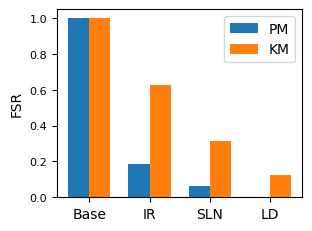

In [97]:
model = 'qwen/qwen2.5-7b-instruct'
num_fp = '16'
fp_algo = 'instructional_fp'

fp_config_hash = "208872d41bc423d910f76141ebf25d3363a700ed79a0400ad9cf24c9443fa1e6"

attack_name_1 = "ImprobableTokenWithThresholdLogitsProcessor"
attack_name_2 = "BlockTopWordLogitProcessor"
attack_name_3 = "LookaheadAttackedModel"

attack_config_1 = '{"num_generated_tokens_to_apply": "1", "threshold": "0.0", "top_k_to_remove": "3"}'
attack_config_2 = '{"lexical_set_size": "4", "num_generated_tokens_to_apply": "1", "num_tokens_to_expand_lexical_set": "1", "top_k_to_perturb": "16"}'
attack_config_3 = '{"beam_k": "10", "beam_steps": "16", "filter_in_question_words": "True", "filter_stop_words": "False", "num_generation_steps_to_suppress": "32", "suppress_delta": "100.0", "suppress_max_pos": "4.4", "suppress_min_appearances": "5", "suppress_min_avg_prob": "0.9", "suppress_min_p": "0.95", "suppress_top_k_appearing": "8", "suppress_top_k_pos": "4", "suppress_top_k_prob": "4"}'

metric_1 = "detailed/fp_in_response_normalized_str_original"
metric_2 = "detailed/fp_in_response_normalized_str"

attack_1_results = (attack_results[model][num_fp][fp_algo][fp_config_hash][attack_name_1][attack_config_1][metric_1][0], attack_results[model][num_fp][fp_algo][fp_config_hash][attack_name_1][attack_config_1][metric_2][0])
attack_2_results = (attack_results[model][num_fp][fp_algo][fp_config_hash][attack_name_2][attack_config_2][metric_1][0], attack_results[model][num_fp][fp_algo][fp_config_hash][attack_name_2][attack_config_2][metric_2][0])
attack_3_results = (attack_results[model][num_fp][fp_algo][fp_config_hash][attack_name_3][attack_config_3][metric_1][0], attack_results[model][num_fp][fp_algo][fp_config_hash][attack_name_3][attack_config_3][metric_2][0])

baseline_results = (1.0, 1.0)

# print(attack_1_results)
# print(attack_2_results)
# print(attack_3_results)
# print(baseline_results)

results = [
    baseline_results,
    attack_1_results,
    attack_2_results,
    attack_3_results,
]
attack_names = ["baseline", attack_name_1, attack_name_2, attack_name_3]
labels = [attack_to_final_name_short[attack_name] for attack_name in attack_names]
# Convert to arrays
results = np.array(results)  # shape (4,2)

x = np.arange(len(results))  # group positions
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=FIG_SIZE_MIDDLE)
#Set x fontsize to FONT_SIZE_MAIN



rects1 = ax.bar(x - width/2, results[:,0], width, label=metric_to_final_name[metric_1])
rects2 = ax.bar(x + width/2, results[:,1], width, label=metric_to_final_name[metric_2])

# Labels and formatting
ax.set_ylabel("FSR")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=FONT_SIZE_MAIN)
ax.legend()

plt.tight_layout()
# plt.show()
plt.savefig("plots/asr_cherry_picked.pdf", bbox_inches='tight', dpi=300)


### Line plot for util/FSR

Prim util points: [[0.         0.73807974]
 [0.25       0.9390693 ]]
Prim util points thresholded: [[0.         0.90673922]]
Prim util points: [[0.         0.8690925 ]
 [0.0625     0.9081334 ]
 [0.1875     0.94522169]]
Prim util points thresholded: [[0.         0.94254129]
 [0.125      0.95954883]]


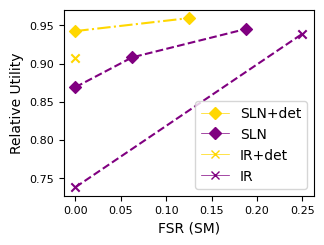

In [122]:
from matplotlib.lines import Line2D

model = 'meta-llama/llama-3.2-1b-instruct'
num_fp = '16'
fp_algo = 'imf'

fp_config_hash = "66caf8423b5f660cee2cae678fa8d12bd62c21a03668cf0ed9315703304b1dce"


res = attack_results[model][num_fp][fp_algo][fp_config_hash]
prim_metric = fp_to_primary_secondary_metric[fp_algo][0]
sec_metric = fp_to_primary_secondary_metric[fp_algo][1]
prim_metric = fp_to_primary_secondary_metric[fp_algo][0]
sec_metric = fp_to_primary_secondary_metric[fp_algo][1]

multi_util_aggregation = max
normalize_utils = True

plot_pareto = True

fig, ax = plt.subplots(figsize=FIG_SIZE_MIDDLE)

baseline_util = baseline_utils[model]
if normalize_utils:
    mean_baseline_util = np.mean([multi_util_aggregation(v) for k,v in baseline_util.items() if k in utils_to_keep])
else:
    mean_baseline_util = 1.0
    
max_x_to_plot = 0.25


for attack_name in res:
    prim_util_points = []
    sec_util_points = []
    
    prim_util_points_thresholded = []
    sec_util_points_thresholded = []
    for attack_config in res[attack_name]:
        attack_utils = get_utils_safely(model, attack_name, attack_config, utils_results, utils_to_keep, multi_util_aggregation=multi_util_aggregation)
        if not attack_utils:
            # print(f"No attack utils for {attack_name} {attack_config}")
            continue
        attack_config_dict = json.loads(attack_config)
        thresholded = False
        for threshold_metric in threshold_params:
            if threshold_metric in attack_config_dict:
                if float(attack_config_dict[threshold_metric]) > 0.0:
                    thresholded = True
                    break
        if thresholded:
            prim_list = prim_util_points_thresholded
            sec_list = sec_util_points_thresholded
        else:
            prim_list = prim_util_points
            sec_list = sec_util_points
            
        for metric in res[attack_name][attack_config]:
            if metric == prim_metric:
                prim_metric_values = res[attack_name][attack_config][metric]
            if metric == sec_metric:
                sec_metric_values = res[attack_name][attack_config][metric]
        prim_metric_value = min(prim_metric_values)
        sec_metric_value = min(sec_metric_values)
        
        prim_list.append((prim_metric_value, np.mean(list(attack_utils.values()))/mean_baseline_util))
        sec_list.append((sec_metric_value, np.mean(list(attack_utils.values()))/mean_baseline_util))

    if prim_util_points:
        if plot_pareto:
            prim_util_points = pareto_points(prim_util_points)
            # sec_util_points = pareto_points(sec_util_points)

        prim_util_points = remove_points(prim_util_points, threshold=0.0, max_x=0.25)
        print(f"Prim util points: {prim_util_points}")
        # sec_util_points = remove_points(sec_util_points, threshold=0.01)
        plt.scatter([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], label=f"{attack_to_final_name_short[attack_name]}-primary", marker=attack_to_shape[attack_name], color=metric_to_color[0])
        plt.plot([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], color=metric_to_color[0], linestyle='--')
        # plt.scatter([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], label=f"{attack_to_final_name_short[attack_name]}-secondary", marker=attack_to_shape[attack_name], color=metric_to_color[1])
        # plt.plot([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], color=metric_to_color[1], linestyle='--')

    if prim_util_points_thresholded:
        if plot_pareto:
            prim_util_points_thresholded = pareto_points(prim_util_points_thresholded)
            # sec_util_points_thresholded = pareto_points(sec_util_points_thresholded)

        prim_util_points_thresholded = remove_points(prim_util_points_thresholded, threshold=0.0, max_x=0.25)
        print(f"Prim util points thresholded: {prim_util_points_thresholded}")
        # sec_util_points_thresholded = remove_points(sec_util_points_thresholded, threshold=0.01)
        plt.scatter([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-primary", marker=attack_to_shape[f"{attack_name}"], color=metric_to_color[1])
        plt.plot([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], color=metric_to_color[1], linestyle='-.')
        # plt.scatter([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-secondary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[1])
        # plt.plot([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], color=metric_to_color[1], linestyle='-.')

plt.xlabel(f'FSR ({metric_to_label[prim_metric]})')
plt.ylabel('Relative Utility')
# Add a custom legend - with P, S for short attack name and color for thresholded
legend_elements = []
for attack_name_ in ["BlockTopWordLogitProcessor", "ImprobableTokenWithThresholdLogitsProcessor"]:
    legend_elements.append(Line2D([0], [0], color=metric_to_color[1], lw=0.5, marker=attack_to_shape[attack_name_], markersize=6, label=f"{attack_to_final_name_short[attack_name_]}+det"))
    legend_elements.append(Line2D([0], [0], color=metric_to_color[0], lw=0.5, marker=attack_to_shape[attack_name_], markersize=6, label=f"{attack_to_final_name_short[attack_name_]}"))
plt.legend(handles=legend_elements, loc='lower right')
plt.savefig(f"plots/asr_vs_util_cherrypicked.pdf", bbox_inches='tight', dpi=300)

## FP algo plots

### All plots

In [ ]:

# actual_util_datasets = {k: v for k, v in util_datasets.items() if k in utils_to_keep}
attack_to_shape = {
    "ImprobableTokenWithThresholdLogitsProcessor": "x",
    "BlockTopWordLogitProcessor": "D",
    "LookaheadAttackedModel": "^",
    
    "ImprobableTokenWithThresholdLogitsProcessor-thresh": "P",
    "BlockTopWordLogitProcessor-thresh": "s",
}

metric_to_color = ["purple", "gold"]

threshold_params = ["threshold", "prob_threshold_to_add_to_lexical_set", "prob_threshold_to_apply_attack"]

sep_thresholded = False
smoothing_threshold = 0.01

use_pareto = True
multi_util_aggregation = max
normalize_utils = True
save_legend = True

max_x_to_plot_primary = 0.5
max_x_to_plot_secondary = 0.8


all_models = list(model_fp_to_hash.keys())
all_num_fps = list(model_fp_to_hash[all_models[0]].keys())
all_fp_algos = list(model_fp_to_hash[all_models[0]][all_num_fps[0]].keys())

for model in all_models:
    baseline_util = baseline_utils[model]
    if normalize_utils:
        all_baseline_utils = []
        for k in utils_to_keep:
            # if k in baseline_util:
            all_baseline_utils.append(multi_util_aggregation(baseline_util[k]))
        
        mean_baseline_util = np.mean(all_baseline_utils)
    else:
        mean_baseline_util = 1.0
    for num_fp in all_num_fps:
        for fp_algo in all_fp_algos:
            if fp_algo == "chain_hash":
                max_x_to_plot_secondary = 0.6
            else:
                max_x_to_plot_secondary = 0.8
            fp_config_hash = model_fp_to_hash[model][num_fp][fp_algo][0]
            if not fp_config_hash:
                continue
            fig, ax = plt.subplots(figsize=FIG_SIZE_SMALL)
            res = attack_results[model][num_fp][fp_algo][fp_config_hash]
            prim_metric = fp_to_primary_secondary_metric[fp_algo][0]
            sec_metric = fp_to_primary_secondary_metric[fp_algo][1]
            
            # Setting to min

            is_plotted = False
            plotted_attack_names = []
            for attack_name in res:
                prim_util_points = []
                sec_util_points = []
                
                prim_util_points_thresholded = []
                sec_util_points_thresholded = []
                
                for attack_config in res[attack_name]:
                    attack_utils = get_utils_safely(model, attack_name, attack_config, utils_results, utils_to_keep, multi_util_aggregation=multi_util_aggregation)
                    if not attack_utils:
                        # print(f"No attack utils for {attack_name} {attack_config}")
                        continue
                    attack_config_dict = json.loads(attack_config)
                    thresholded = False
                    for threshold_metric in threshold_params:
                        if threshold_metric in attack_config_dict:
                            if float(attack_config_dict[threshold_metric]) > 0.0:
                                thresholded = True
                                break
                    if thresholded and sep_thresholded:
                        prim_list = prim_util_points_thresholded
                        sec_list = sec_util_points_thresholded
                    else:
                        prim_list = prim_util_points
                        sec_list = sec_util_points
                        
                    for metric in res[attack_name][attack_config]:
                        if metric == prim_metric:
                            prim_metric_values = res[attack_name][attack_config][metric]
                        if metric == sec_metric:
                            sec_metric_values = res[attack_name][attack_config][metric]


                    # Setting to min
                    prim_metric_value = min(prim_metric_values)
                    sec_metric_value = min(sec_metric_values)
                    
                    prim_list.append((prim_metric_value, np.mean(list(attack_utils.values())) /mean_baseline_util))
                    sec_list.append((sec_metric_value, np.mean(list(attack_utils.values())) /mean_baseline_util))
                

                if prim_util_points:
                    if use_pareto:
                        prim_util_points = pareto_points(prim_util_points)
                        sec_util_points = pareto_points(sec_util_points)
                    prim_util_points = remove_points(prim_util_points, threshold=smoothing_threshold, max_x=max_x_to_plot)
                    sec_util_points = remove_points(sec_util_points, threshold=smoothing_threshold, max_x=max_x_to_plot_secondary)
                        
                    plt.scatter([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], label=f"{attack_to_final_name_short[attack_name]}-primary", marker=attack_to_shape[attack_name], color=metric_to_color[0])
                    plt.plot([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], color=metric_to_color[0], linestyle='--')
                    plt.scatter([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], label=f"{attack_to_final_name_short[attack_name]}-secondary", marker=attack_to_shape[attack_name], color=metric_to_color[1])
                    plt.plot([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], color=metric_to_color[1], linestyle='-.')
                    is_plotted = True
                    plotted_attack_names.append(attack_name)

                if prim_util_points_thresholded:
                    if use_pareto:
                        prim_util_points_thresholded = pareto_points(prim_util_points_thresholded, threshold=smoothing_threshold)
                        sec_util_points_thresholded = pareto_points(sec_util_points_thresholded, threshold=smoothing_threshold)
                    prim_util_points_thresholded = remove_points(prim_util_points_thresholded, threshold=smoothing_threshold, max_x=max_x_to_plot)
                    sec_util_points_thresholded = remove_points(sec_util_points_thresholded, threshold=smoothing_threshold, max_x=max_x_to_plot_secondary)
                        
                    plt.scatter([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-primary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[0])
                    plt.plot([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], color=metric_to_color[0], linestyle='--')
                    plt.scatter([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-secondary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[1])
                    plt.plot([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], color=metric_to_color[1], linestyle='-.')
                    is_plotted = True
                    plotted_attack_names.append(attack_name)

            if is_plotted:
                # plt.title(f"{model} {num_fp} {fp_algo}")
                plt.xlabel(f"FSR")
                plt.ylabel(f"Normalized Utility")
                plt.title(f"{model_to_label[model]}")
                plt.grid(True, alpha=0.7)
                plt.savefig(f"plots/detailed/asr_vs_util_{model.split('/')[-1]}_{num_fp}_{fp_algo}.pdf", bbox_inches='tight', dpi=300)
                plt.close()

                # Make a common legend: FIG_SIZE_SMALL, single row, no title, no axes.
                from matplotlib.lines import Line2D
                if save_legend:
                    # Collect which marker-keys were actually plotted in this figure
                    # We rebuild by checking presence of points again to avoid new state variables.
                    plotted_marker_keys = set()
                    for attack_name in plotted_attack_names:
                        # Primary/secondary
                        if attack_name in attack_to_shape:
                            # If any data existed it would have been plotted; be conservative:
                            plotted_marker_keys.add(attack_name)
                        # Thresholded variant shape only if configured
                        if sep_thresholded:
                            thresh_key = f"{attack_name}-thresh"
                            if thresh_key in attack_to_shape:
                                # Same conservative inclusion
                                plotted_marker_keys.add(thresh_key)

                    # Build attack marker handles
                    attack_handles = []
                    for key in sorted(plotted_marker_keys):
                        base_name = key.replace("-thresh", "")
                        label = attack_to_final_name_short.get(base_name, base_name)
                        if key.endswith("-thresh"):
                            label = f"{label}-++"
                        attack_handles.append(
                            Line2D([0], [0],
                                marker=attack_to_shape[key],
                                linestyle='None',
                               markerfacecolor='black',
                               markeredgecolor='black',
                                label=label)
                        )

                    # Build metric color handles
                    metric_handles = [
                        Line2D([0], [0],marker='s', color=metric_to_color[0],
                           markerfacecolor=metric_to_color[0],
                           markeredgecolor='black',
                           linestyle='--', label=f"{metric_to_label[prim_metric]}"),
                        Line2D([0], [0], marker='s', color=metric_to_color[1],
                           markerfacecolor=metric_to_color[1],
                           markeredgecolor='black', linestyle='-.', label=f"{metric_to_label[sec_metric]}"),
                    ]

                    # handles = attack_handles + metric_handles
                    # if handles:
                    #     legend_ax.legend(handles=handles, loc='center', ncol=len(handles), frameon=False)
                    group_handles = [
                    Line2D([0], [0], linestyle='None', label="Attack:"),
                    *attack_handles,
                    Line2D([0], [0], linestyle='None', label=" FSR Metric:"),
                    *metric_handles
                    ]

                    legend_fig, legend_ax = plt.subplots(figsize=(FIG_SIZE_BIG[0], 0.1))
                    legend_ax.axis('off')
                    if group_handles:
                        legend_ax.legend(handles=group_handles, loc='center',
                                            ncol=len(group_handles),
                                            fontsize=FONT_SIZE_MAIN,
                                            frameon=False,
                                            borderaxespad=0.0,          # cut outer padding
                                            # handleheight=1.0            # tighten row height
                                            )
                        legend_fig.savefig(f"plots/detailed/legend_{fp_algo}.pdf",
                                            bbox_inches='tight', dpi=300)
                    plt.close(legend_fig)


### Plotting models together

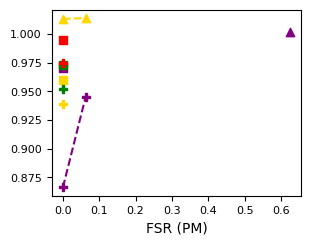

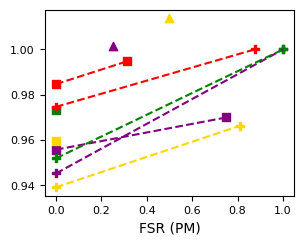

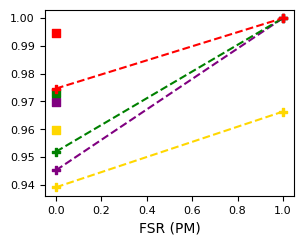

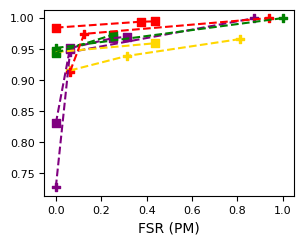

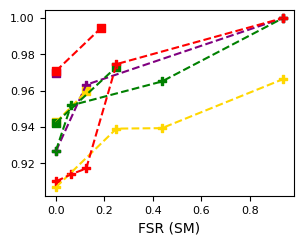

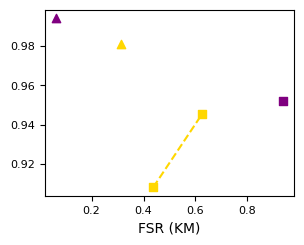

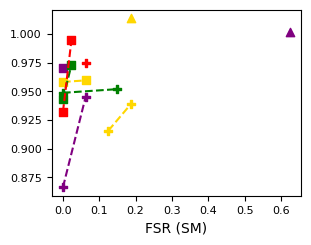

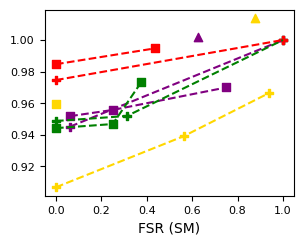

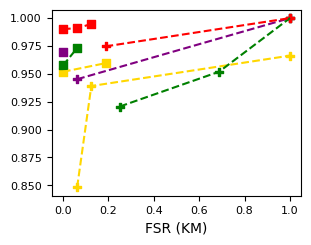

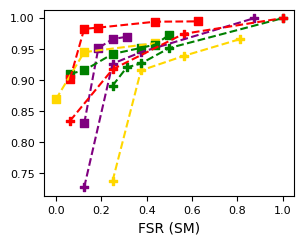

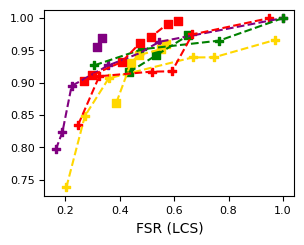

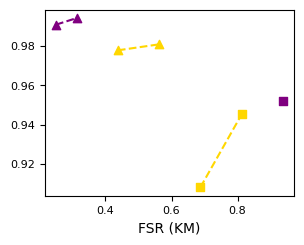

In [125]:
attack_to_shape = {
    "ImprobableTokenWithThresholdLogitsProcessor": "P",
    "BlockTopWordLogitProcessor": "s",
    "LookaheadAttackedModel": "^",
    
    "ImprobableTokenWithThresholdLogitsProcessor-thresh": "x",
    "BlockTopWordLogitProcessor-thresh": "D",
}
metric_to_color = ["purple", "gold", "green", "red"]

threshold_params = ["threshold", "prob_threshold_to_add_to_lexical_set", "prob_threshold_to_apply_attack"]

sep_thresholded = False
smoothing_threshold = 0.02


use_pareto = True
multi_util_aggregation = max
normalize_utils = True


all_models = [
    'qwen/qwen2.5-1.5b-instruct', 
    'meta-llama/llama-3.2-1b-instruct',
    'qwen/qwen2.5-7b-instruct', 
    'meta-llama/llama-3.1-8b-instruct',
              
              ]
all_num_fps = ['16']
all_fp_algos = list(model_fp_to_hash[all_models[0]][all_num_fps[0]].keys())

plotting_mode = "secondary"

for plotting_mode in ["primary", "secondary"]:
    for fp_algo in all_fp_algos:
        for num_fp in all_num_fps:
            fig, ax = plt.subplots(figsize=FIG_SIZE_MIDDLE)
            prim_metric = fp_to_primary_secondary_metric[fp_algo][0]
            sec_metric = fp_to_primary_secondary_metric[fp_algo][1]
            
            if plotting_mode == "primary":
                ax.set_xlabel(f"FSR ({metric_to_label[prim_metric]})")
            elif plotting_mode == "secondary":
                ax.set_xlabel(f"FSR ({metric_to_label[sec_metric]})")
                    
            for model in all_models:
                baseline_util = baseline_utils[model]
                if normalize_utils:
                    mean_baseline_util = np.mean([multi_util_aggregation(v) for k,v in baseline_util.items() if k in utils_to_keep])
                else:
                    mean_baseline_util = 0.0
                fp_config_hash = model_fp_to_hash[model][num_fp][fp_algo][0]
                if not fp_config_hash:
                    continue
                res = attack_results[model][num_fp][fp_algo][fp_config_hash]
                
                # Setting to min

                is_plotted = False
                for attack_name in res:
                    prim_util_points = []
                    sec_util_points = []
                    
                    prim_util_points_thresholded = []
                    sec_util_points_thresholded = []
                    
                    for attack_config in res[attack_name]:
                        attack_utils = get_utils_safely(model, attack_name, attack_config, utils_results, utils_to_keep, multi_util_aggregation=multi_util_aggregation)
                        if not attack_utils:
                            # print(f"No attack utils for {attack_name} {attack_config}")
                            continue
                        attack_config_dict = json.loads(attack_config)
                        thresholded = False
                        for threshold_metric in threshold_params:
                            if threshold_metric in attack_config_dict:
                                if float(attack_config_dict[threshold_metric]) > 0.0:
                                    thresholded = True
                                    break
                        if thresholded and sep_thresholded:
                            prim_list = prim_util_points_thresholded
                            sec_list = sec_util_points_thresholded
                        else:
                            prim_list = prim_util_points
                            sec_list = sec_util_points
                            
                        for metric in res[attack_name][attack_config]:
                            if metric == prim_metric:
                                prim_metric_values = res[attack_name][attack_config][metric]
                            if metric == sec_metric:
                                sec_metric_values = res[attack_name][attack_config][metric]

                        # Setting to min
                        prim_metric_value = min(prim_metric_values)
                        sec_metric_value = min(sec_metric_values)
                        
                        
                        prim_list.append((prim_metric_value, np.mean(list(attack_utils.values()))/mean_baseline_util))
                        sec_list.append((sec_metric_value, np.mean(list(attack_utils.values()))/mean_baseline_util))
                    

                    if prim_util_points:
                        if use_pareto:
                            prim_util_points = pareto_points(prim_util_points)
                            sec_util_points = pareto_points(sec_util_points)
                        prim_util_points = remove_points(prim_util_points, threshold=smoothing_threshold)
                        sec_util_points = remove_points(sec_util_points, threshold=smoothing_threshold)
                        if plotting_mode == "primary":
                            plt.scatter([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], label=f"{attack_to_final_name_short[attack_name]}-primary", marker=attack_to_shape[attack_name], color=metric_to_color[all_models.index(model)])
                            plt.plot([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], color=metric_to_color[all_models.index(model)], linestyle='--')
                        elif plotting_mode == "secondary":
                            plt.scatter([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], label=f"{attack_to_final_name_short[attack_name]}-secondary", marker=attack_to_shape[attack_name], color=metric_to_color[all_models.index(model)])
                            plt.plot([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], color=metric_to_color[all_models.index(model)], linestyle='--')
                        is_plotted = True

                    if prim_util_points_thresholded:

                        if use_pareto:
                            prim_util_points_thresholded = pareto_points(prim_util_points_thresholded)
                            sec_util_points_thresholded = pareto_points(sec_util_points_thresholded)
                        prim_util_points_thresholded = remove_points(prim_util_points_thresholded, threshold=smoothing_threshold)
                        sec_util_points_thresholded = remove_points(sec_util_points_thresholded, threshold=smoothing_threshold)
                        if plotting_mode == "primary":
                            plt.scatter([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-primary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[all_models.index(model)])
                            plt.plot([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], color=metric_to_color[all_models.index(model)], linestyle='-.')
                        elif plotting_mode == "secondary":
                            plt.scatter([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-secondary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[all_models.index(model)])
                            plt.plot([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], color=metric_to_color[all_models.index(model)], linestyle='-.')
                        is_plotted = True
                    


### Chain Hash

## Preview

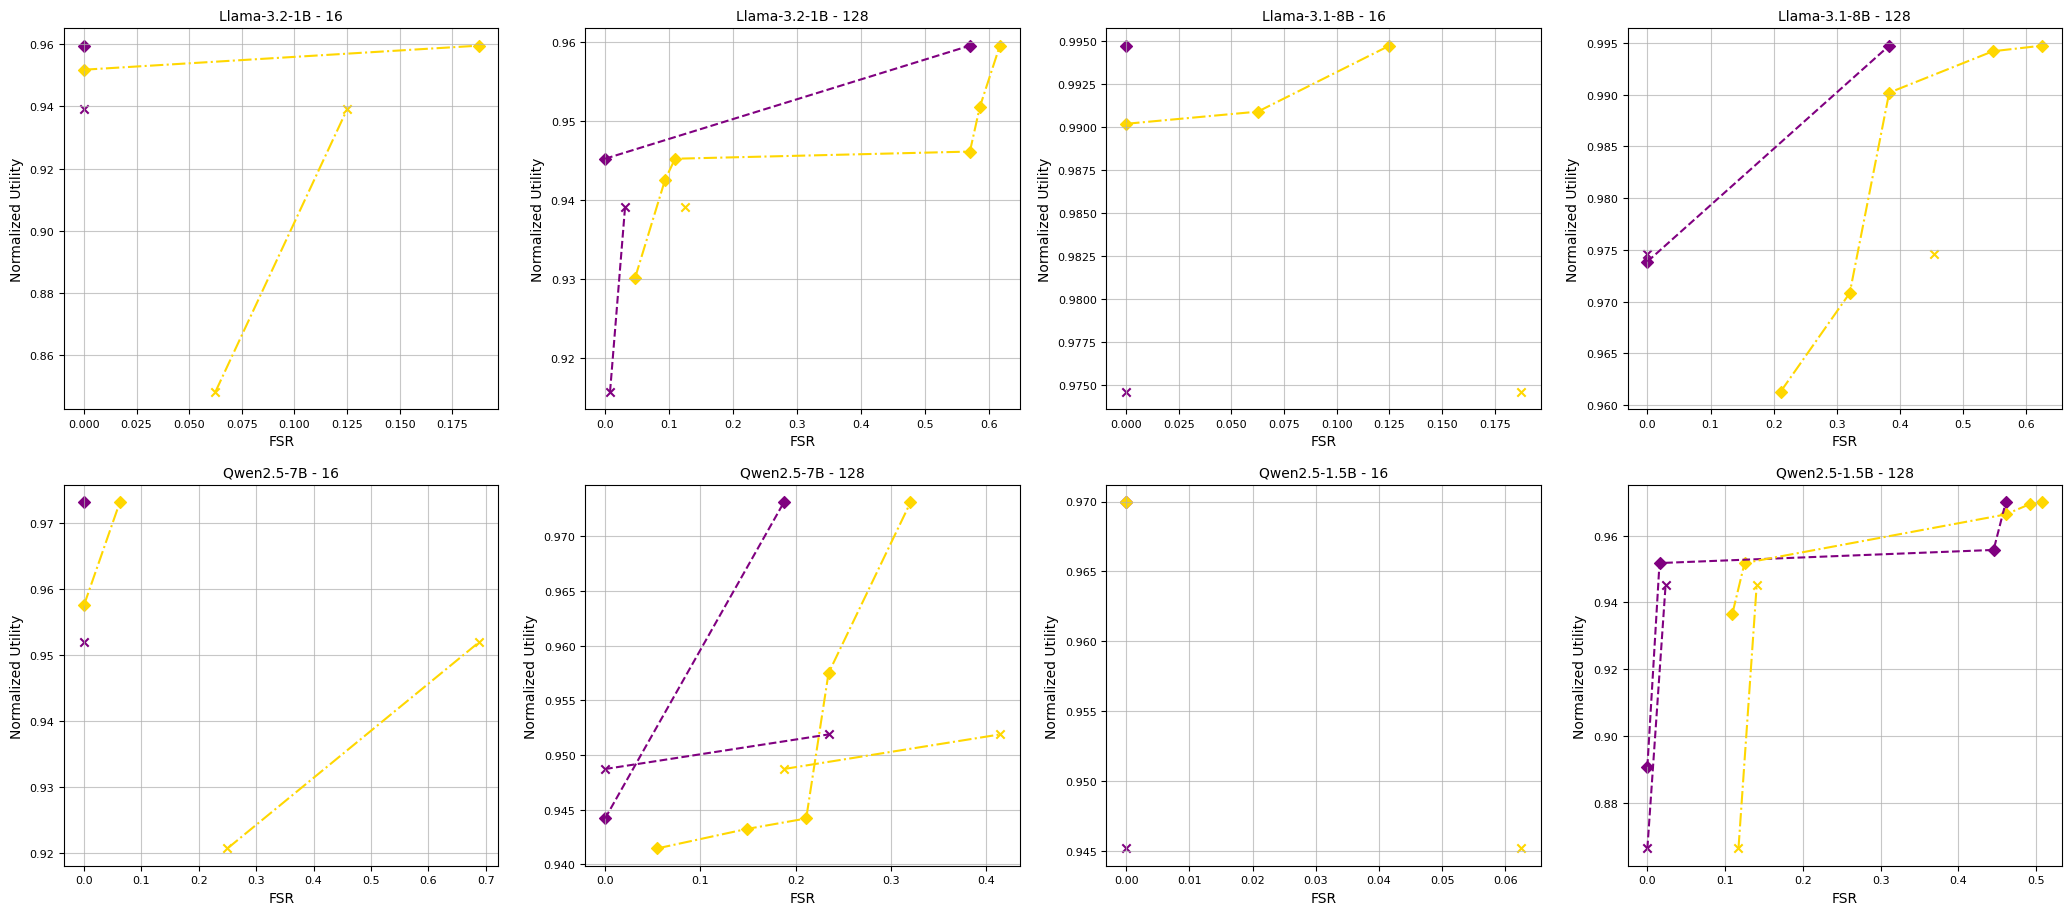

In [155]:

# actual_util_datasets = {k: v for k, v in util_datasets.items() if k in utils_to_keep}
attack_to_shape = {
    "ImprobableTokenWithThresholdLogitsProcessor": "x",
    "BlockTopWordLogitProcessor": "D",
    "LookaheadAttackedModel": "^",
    
    "ImprobableTokenWithThresholdLogitsProcessor-thresh": "P",
    "BlockTopWordLogitProcessor-thresh": "s",
}

metric_to_color = ["purple", "gold"]

threshold_params = ["threshold", "prob_threshold_to_add_to_lexical_set", "prob_threshold_to_apply_attack"]

sep_thresholded = False
smoothing_threshold = 0.01

use_pareto = True
multi_util_aggregation = max
normalize_utils = True
save_legend = True

max_x_to_plot_primary = 0.5
max_x_to_plot_secondary = 0.8


all_models = list(model_fp_to_hash.keys())
all_num_fps = list(model_fp_to_hash[all_models[0]].keys())
all_fp_algos = list(model_fp_to_hash[all_models[0]][all_num_fps[0]].keys())

fig, ax = plt.subplots(2, 4, figsize=(8*FIG_SIZE_MIDDLE[0], 4.5*FIG_SIZE_MIDDLE[1]))

idx = -1
for model in all_models:
    baseline_util = baseline_utils[model]
    if normalize_utils:
        all_baseline_utils = []
        for k in utils_to_keep:
            # if k in baseline_util:
            all_baseline_utils.append(multi_util_aggregation(baseline_util[k]))
        
        mean_baseline_util = np.mean(all_baseline_utils)
    else:
        mean_baseline_util = 1.0
    for num_fp in all_num_fps:
        idx += 1
        for fp_algo in ['perinucleus']:
            if fp_algo == "chain_hash":
                max_x_to_plot_secondary = 0.6
            else:
                max_x_to_plot_secondary = 0.8
            fp_config_hash = model_fp_to_hash[model][num_fp][fp_algo][0]
            if not fp_config_hash:
                continue
            res = attack_results[model][num_fp][fp_algo][fp_config_hash]
            prim_metric = fp_to_primary_secondary_metric[fp_algo][0]
            sec_metric = fp_to_primary_secondary_metric[fp_algo][1]
            
            # Setting to min

            is_plotted = False
            plotted_attack_names = []
            for attack_name in res:
                prim_util_points = []
                sec_util_points = []
                
                prim_util_points_thresholded = []
                sec_util_points_thresholded = []
                
                for attack_config in res[attack_name]:
                    attack_utils = get_utils_safely(model, attack_name, attack_config, utils_results, utils_to_keep, multi_util_aggregation=multi_util_aggregation)
                    if not attack_utils:
                        # print(f"No attack utils for {attack_name} {attack_config}")
                        continue
                    attack_config_dict = json.loads(attack_config)
                    thresholded = False
                    for threshold_metric in threshold_params:
                        if threshold_metric in attack_config_dict:
                            if float(attack_config_dict[threshold_metric]) > 0.0:
                                thresholded = True
                                break
                    if thresholded and sep_thresholded:
                        prim_list = prim_util_points_thresholded
                        sec_list = sec_util_points_thresholded
                    else:
                        prim_list = prim_util_points
                        sec_list = sec_util_points
                        
                    for metric in res[attack_name][attack_config]:
                        if metric == prim_metric:
                            prim_metric_values = res[attack_name][attack_config][metric]
                        if metric == sec_metric:
                            sec_metric_values = res[attack_name][attack_config][metric]


                    # Setting to min
                    prim_metric_value = min(prim_metric_values)
                    sec_metric_value = min(sec_metric_values)
                    
                    prim_list.append((prim_metric_value, np.mean(list(attack_utils.values())) /mean_baseline_util))
                    sec_list.append((sec_metric_value, np.mean(list(attack_utils.values())) /mean_baseline_util))
                

                if prim_util_points:
                    if use_pareto:
                        prim_util_points = pareto_points(prim_util_points)
                        sec_util_points = pareto_points(sec_util_points)
                    prim_util_points = remove_points(prim_util_points, threshold=smoothing_threshold, max_x=max_x_to_plot)
                    sec_util_points = remove_points(sec_util_points, threshold=smoothing_threshold, max_x=max_x_to_plot_secondary)
                        
                    ax[idx // 4, idx % 4].scatter([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], label=f"{attack_to_final_name_short[attack_name]}-primary", marker=attack_to_shape[attack_name], color=metric_to_color[0])
                    ax[idx // 4, idx % 4].plot([x[0] for x in prim_util_points], [x[1] for x in prim_util_points], color=metric_to_color[0], linestyle='--')
                    ax[idx // 4, idx % 4].scatter([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], label=f"{attack_to_final_name_short[attack_name]}-secondary", marker=attack_to_shape[attack_name], color=metric_to_color[1])
                    ax[idx // 4, idx % 4].plot([x[0] for x in sec_util_points], [x[1] for x in sec_util_points], color=metric_to_color[1], linestyle='-.')
                    is_plotted = True
                    plotted_attack_names.append(attack_name)

                if prim_util_points_thresholded:
                    if use_pareto:
                        prim_util_points_thresholded = pareto_points(prim_util_points_thresholded, threshold=smoothing_threshold)
                        sec_util_points_thresholded = pareto_points(sec_util_points_thresholded, threshold=smoothing_threshold)
                    prim_util_points_thresholded = remove_points(prim_util_points_thresholded, threshold=smoothing_threshold, max_x=max_x_to_plot)
                    sec_util_points_thresholded = remove_points(sec_util_points_thresholded, threshold=smoothing_threshold, max_x=max_x_to_plot_secondary)
                        
                    ax[idx // 4, idx % 4].scatter([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-primary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[0])
                    ax[idx // 4, idx % 4].plot([x[0] for x in prim_util_points_thresholded], [x[1] for x in prim_util_points_thresholded], color=metric_to_color[0], linestyle='--')
                    ax[idx // 4, idx % 4].scatter([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], label=f"{attack_to_final_name_short[attack_name]}-++-secondary", marker=attack_to_shape[f"{attack_name}-thresh"], color=metric_to_color[1])
                    ax[idx // 4, idx % 4].plot([x[0] for x in sec_util_points_thresholded], [x[1] for x in sec_util_points_thresholded], color=metric_to_color[1], linestyle='-.')
                    is_plotted = True
                    plotted_attack_names.append(attack_name)

            if is_plotted:
                # plt.title(f"{model} {num_fp} {fp_algo}")
                ax[idx // 4, idx % 4].set_xlabel(f"FSR")
                ax[idx // 4, idx % 4].set_ylabel(f"Normalized Utility")
                ax[idx // 4, idx % 4].set_title(f"{model_to_label[model]} - {num_fp}")
                ax[idx // 4, idx % 4].grid(True, alpha=0.7)

                # plt.show()
                # Make a common legend: FIG_SIZE_SMALL, single row, no title, no axes.
                from matplotlib.lines import Line2D
                if save_legend:
                    # Collect which marker-keys were actually plotted in this figure
                    # We rebuild by checking presence of points again to avoid new state variables.
                    plotted_marker_keys = set()
                    for attack_name in plotted_attack_names:
                        # Primary/secondary
                        if attack_name in attack_to_shape:
                            # If any data existed it would have been plotted; be conservative:
                            plotted_marker_keys.add(attack_name)
                        # Thresholded variant shape only if configured
                        if sep_thresholded:
                            thresh_key = f"{attack_name}-thresh"
                            if thresh_key in attack_to_shape:
                                # Same conservative inclusion
                                plotted_marker_keys.add(thresh_key)

                    # Build attack marker handles
                    attack_handles = []
                    for key in sorted(plotted_marker_keys):
                        base_name = key.replace("-thresh", "")
                        label = attack_to_final_name_short.get(base_name, base_name)
                        if key.endswith("-thresh"):
                            label = f"{label}-++"
                        attack_handles.append(
                            Line2D([0], [0],
                                marker=attack_to_shape[key],
                                linestyle='None',
                               markerfacecolor='black',
                               markeredgecolor='black',
                                label=label)
                        )

                    # Build metric color handles
                    metric_handles = [
                        Line2D([0], [0],marker='s', color=metric_to_color[0],
                           markerfacecolor=metric_to_color[0],
                           markeredgecolor='black',
                           linestyle='--', label=f"{metric_to_label[prim_metric]}"),
                        Line2D([0], [0], marker='s', color=metric_to_color[1],
                           markerfacecolor=metric_to_color[1],
                           markeredgecolor='black', linestyle='-.', label=f"{metric_to_label[sec_metric]}"),
                    ]

                    # handles = attack_handles + metric_handles
                    # if handles:
                    #     legend_ax.legend(handles=handles, loc='center', ncol=len(handles), frameon=False)
                    group_handles = [
                    Line2D([0], [0], linestyle='None', label="Attack:"),
                    *attack_handles,
                    Line2D([0], [0], linestyle='None', label=" FSR Metric:"),
                    *metric_handles
                    ]

                    legend_fig, legend_ax = plt.subplots(figsize=(FIG_SIZE_BIG[0], 0.1))
                    legend_ax.axis('off')
                    if group_handles:
                        legend_ax.legend(handles=group_handles, loc='center',
                                            ncol=len(group_handles),
                                            fontsize=FONT_SIZE_MAIN,
                                            frameon=False,
                                            borderaxespad=0.0,          # cut outer padding
                                            # handleheight=1.0            # tighten row height
                                            )
                    plt.close(legend_fig)


### Instructional FP

### FPEdit

### EditMF

### ImF